# Indoor vs Outdoor Environment Analysis

This notebook analyzes the relationship and correlation between the indoor tracking sensors (`indoor_data.json`) and outdoor weather API data (`tomorrow_recent_data.json`). We align both datasets via time to understand how outdoor conditions influence the indoor environment over time.


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Data Loading and Resampling


In [2]:
# 1.1 Load Indoor Data
with open('../data/indoor_data.json', 'r') as f:
    indoor_raw = json.load(f)

indoor_records = [{'datetime': pd.to_datetime(e['time']), 'in_temp': e['values']['temperature'], 'in_humidity': e['values']['humidity']} for e in indoor_raw]
indoor_df = pd.DataFrame(indoor_records)

# The indoor data is extremely granular (per ~30 min). 
# We set datetime as index and resample to Hourly to match outdoor data.
indoor_df.set_index('datetime', inplace=True)
indoor_hourly = indoor_df.resample('1h').mean().reset_index()

# 1.2 Load Outdoor Data
with open('../data/tomorrow_recent_data.json', 'r') as f:
    outdoor_raw = json.load(f)
outdoor_records = []
for entry in outdoor_raw:
    row = entry['Values'].copy()
    row['datetime'] = pd.to_datetime(entry['time'])
    outdoor_records.append(row)
outdoor_df = pd.DataFrame(outdoor_records)

# Extract relevant outdoor features and add prefix to avoid confusion
outdoor_features = ['temperature', 'humidity', 'dewPoint', 'uvIndex', 'cloudCover', 'windSpeed']
outdoor_df = outdoor_df[['datetime'] + outdoor_features].rename(columns={f: f'out_{f}' for f in outdoor_features})

display(indoor_hourly.head())


,datetime,in_temp,in_humidity
0,2026-02-18 00:00:00+00:00,23.5,57.5
1,2026-02-18 01:00:00+00:00,23.0,60.0
2,2026-02-18 02:00:00+00:00,22.0,62.5
3,2026-02-18 03:00:00+00:00,22.0,63.0
4,2026-02-18 04:00:00+00:00,21.0,61.0


## 2. Temporal Alignment and Merging


In [3]:
# Merge on datetime (both are hourly now)
merged_env = pd.merge(indoor_hourly, outdoor_df, on='datetime', how='inner').dropna()

# Add basic time features
merged_env['hour'] = merged_env['datetime'].dt.hour
merged_env['day_of_week'] = merged_env['datetime'].dt.dayofweek

display(merged_env.head())


,datetime,in_temp,in_humidity,out_temperature,out_humidity,out_dewPoint,out_uvIndex,out_cloudCover,out_windSpeed,hour,day_of_week
0,2026-02-18 00:00:00+00:00,23.5,57.5,2.76,72,-2.2,0,100.0,0.8,0,2
1,2026-02-18 01:00:00+00:00,23.0,60.0,2.69,73,-2.0,0,100.0,1.1,1,2
2,2026-02-18 02:00:00+00:00,22.0,62.5,2.92,74,-2.1,0,100.0,1.1,2,2
3,2026-02-18 03:00:00+00:00,22.0,63.0,3.14,74,-2.3,0,100.0,1.0,3,2
4,2026-02-18 04:00:00+00:00,21.0,61.0,3.22,74,-2.3,0,100.0,0.8,4,2


## 3. Correlation Analysis


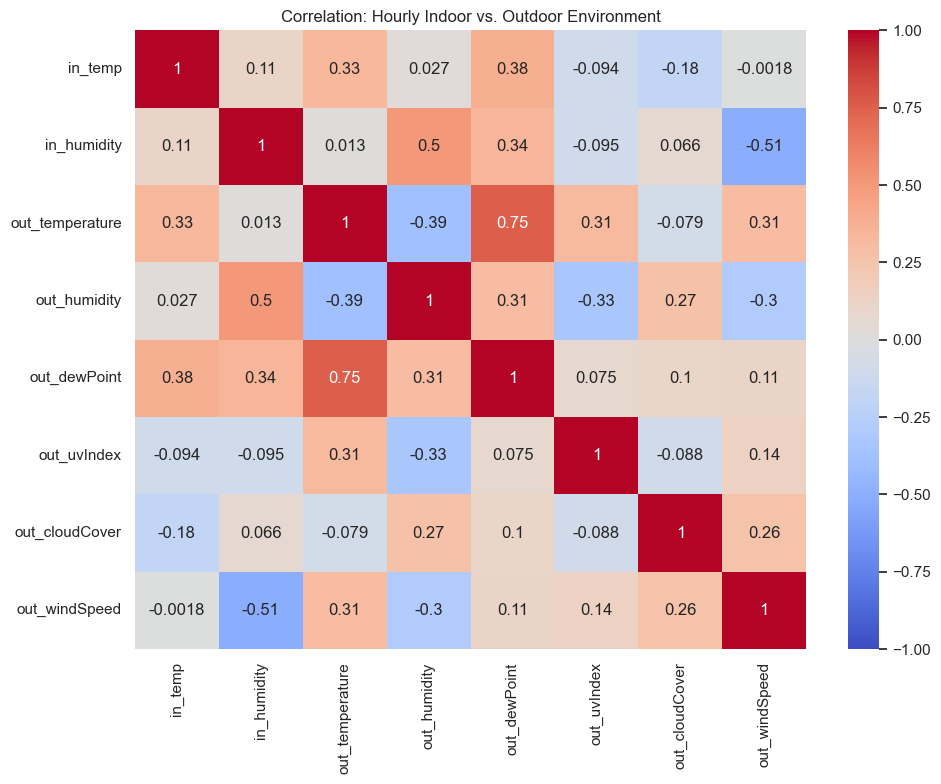

--- Outdoor factors most correlated with Indoor Temperature ---
out_dewPoint       0.384761
out_temperature    0.329001
in_humidity        0.109654
out_humidity       0.026843
out_windSpeed     -0.001815
out_uvIndex       -0.093839
out_cloudCover    -0.182757
Name: in_temp, dtype: float64

--- Outdoor factors most correlated with Indoor Humidity ---
out_humidity       0.500004
out_dewPoint       0.343813
in_temp            0.109654
out_cloudCover     0.066323
out_temperature    0.013448
out_uvIndex       -0.094673
out_windSpeed     -0.512404
Name: in_humidity, dtype: float64


In [4]:
# Let's see how much outdoor variables correlate with indoor ones.
# We care mainly about how 'in_temp' and 'in_humidity' move.
env_cols = ['in_temp', 'in_humidity'] + [c for c in merged_env.columns if c.startswith('out_')]

corr_matrix = merged_env[env_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation: Hourly Indoor vs. Outdoor Environment')
plt.tight_layout()
plt.show()

print("--- Outdoor factors most correlated with Indoor Temperature ---")
print(corr_matrix['in_temp'].sort_values(ascending=False).drop('in_temp'))

print("\n--- Outdoor factors most correlated with Indoor Humidity ---")
print(corr_matrix['in_humidity'].sort_values(ascending=False).drop('in_humidity'))


## 4. Time-Series Visual Comparison


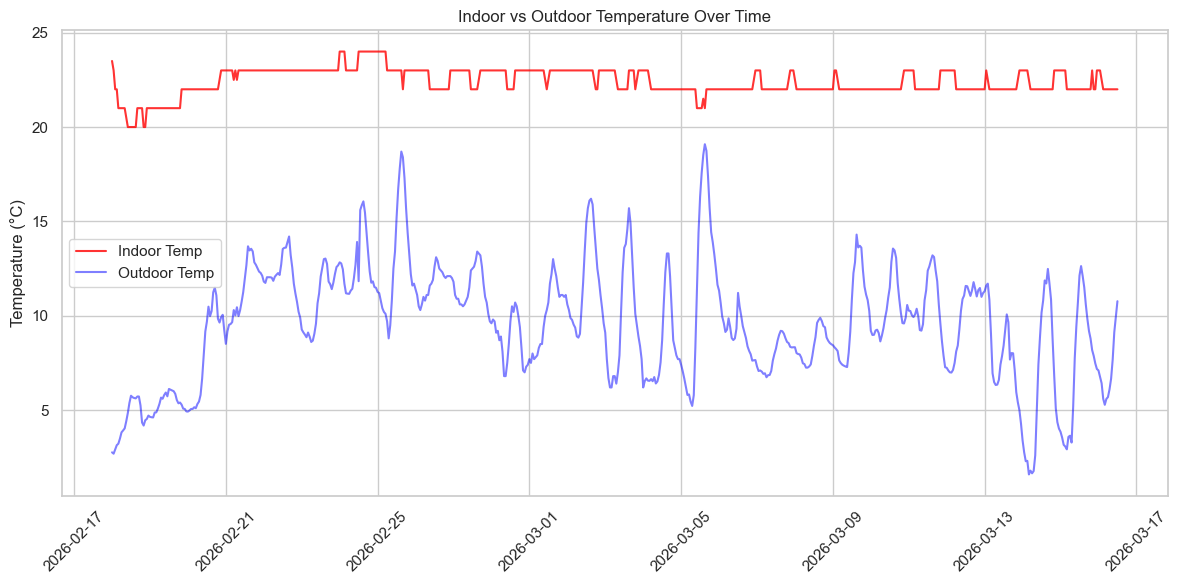

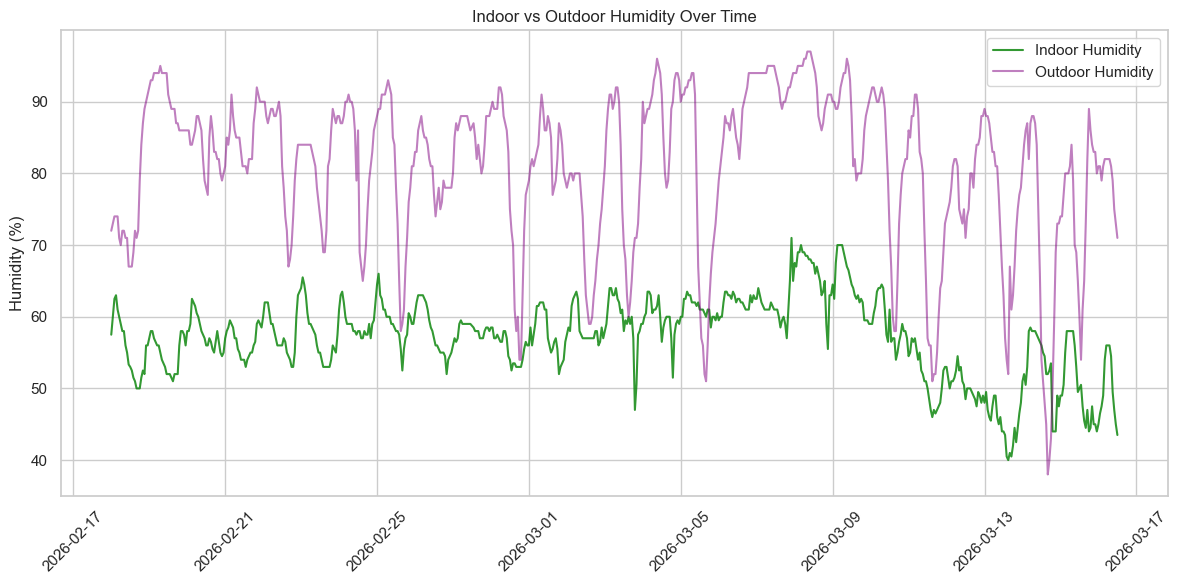

In [5]:
# Plotting Temperature over time
plt.figure()
plt.plot(merged_env['datetime'], merged_env['in_temp'], label='Indoor Temp', color='red', alpha=0.8)
plt.plot(merged_env['datetime'], merged_env['out_temperature'], label='Outdoor Temp', color='blue', alpha=0.5)
plt.title('Indoor vs Outdoor Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Humidity over time
plt.figure()
plt.plot(merged_env['datetime'], merged_env['in_humidity'], label='Indoor Humidity', color='green', alpha=0.8)
plt.plot(merged_env['datetime'], merged_env['out_humidity'], label='Outdoor Humidity', color='purple', alpha=0.5)
plt.title('Indoor vs Outdoor Humidity Over Time')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


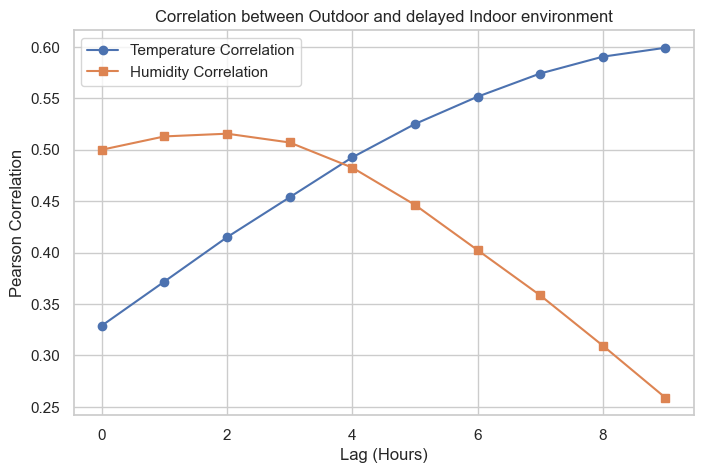

Peak Temperature Correlation occurs at a 9 hour delay (r=0.599).
Peak Humidity Correlation occurs at a 2 hour delay (r=0.516).


In [6]:
# Analyze Time Lag (Does outdoor temp take an hour or two to affect inside?)
# We shift the indoor series backwards to see if past outdoor temp correlates better with current indoor temp.
max_lags = 10
corrs = []

for lag in range(max_lags):
    temp_corr = merged_env['out_temperature'].corr(merged_env['in_temp'].shift(-lag))
    hum_corr = merged_env['out_humidity'].corr(merged_env['in_humidity'].shift(-lag))
    corrs.append({'lag_hours': lag, 'temp_corr': temp_corr, 'hum_corr': hum_corr})

lag_df = pd.DataFrame(corrs)

plt.figure(figsize=(8, 5))
plt.plot(lag_df['lag_hours'], lag_df['temp_corr'], marker='o', label='Temperature Correlation')
plt.plot(lag_df['lag_hours'], lag_df['hum_corr'], marker='s', label='Humidity Correlation')
plt.title('Correlation between Outdoor and delayed Indoor environment')
plt.xlabel('Lag (Hours)')
plt.ylabel('Pearson Correlation')
plt.legend()
plt.grid(True)
plt.show()

best_temp_lag = lag_df.loc[lag_df['temp_corr'].idxmax()]
best_hum_lag = lag_df.loc[lag_df['hum_corr'].idxmax()]

print(f"Peak Temperature Correlation occurs at a {int(best_temp_lag['lag_hours'])} hour delay (r={best_temp_lag['temp_corr']:.3f}).")
print(f"Peak Humidity Correlation occurs at a {int(best_hum_lag['lag_hours'])} hour delay (r={best_hum_lag['hum_corr']:.3f}).")
